In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.integrate import quad

In [3]:
url_data = ("https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease"
            "/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat")
url_cov  = ("https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease"
            "/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/"
            "Pantheon%2BSH0ES_STAT%2BSYS.cov")
 
print("Caricando il dataset...")
df = pd.read_csv(url_data, sep=r'\s+')
print(f"Colonne disponibili:\n{list(df.columns)}\n")
print(f"Supernovae totali: {len(df)}")
 
# Filtro cosmologico standard
mask   = df["zHD"] > 0.01
df_cos = df[mask].reset_index(drop=True)
print(f"Supernovae dopo taglio z>0.01: {len(df_cos)}")
 
# Carica matrice di covarianza
print("\nCaricando la matrice di covarianza...")
import requests, io
r        = requests.get(url_cov)
lines    = r.text.split()
n_cov    = int(lines[0])
cov_flat = np.array(lines[1:], dtype=float)
cov_full = cov_flat.reshape(n_cov, n_cov)
 
# Applica lo stesso filtro alla covarianza
idx = np.where(mask.values)[0]
cov = cov_full[np.ix_(idx, idx)]
print(f"Matrice di covarianza: {cov.shape}")
 
# Shorthand per le variabili principali
z      = df_cos["zHD"].values
mu_obs = df_cos["MU_SH0ES"].values
mu_err = df_cos["MU_SH0ES_ERR_DIAG"].values
 
# Survey ID: ogni numero corrisponde a un survey diverso
# (SDSS=10, SNLS=5, PS1=15, ecc. — vedi README del dataset)
surveys = df_cos["IDSURVEY"].values


Caricando il dataset...
Colonne disponibili:
['CID', 'IDSURVEY', 'zHD', 'zHDERR', 'zCMB', 'zCMBERR', 'zHEL', 'zHELERR', 'm_b_corr', 'm_b_corr_err_DIAG', 'MU_SH0ES', 'MU_SH0ES_ERR_DIAG', 'CEPH_DIST', 'IS_CALIBRATOR', 'USED_IN_SH0ES_HF', 'c', 'cERR', 'x1', 'x1ERR', 'mB', 'mBERR', 'x0', 'x0ERR', 'COV_x1_c', 'COV_x1_x0', 'COV_c_x0', 'RA', 'DEC', 'HOST_RA', 'HOST_DEC', 'HOST_ANGSEP', 'VPEC', 'VPECERR', 'MWEBV', 'HOST_LOGMASS', 'HOST_LOGMASS_ERR', 'PKMJD', 'PKMJDERR', 'NDOF', 'FITCHI2', 'FITPROB', 'm_b_corr_err_RAW', 'm_b_corr_err_VPEC', 'biasCor_m_b', 'biasCorErr_m_b', 'biasCor_m_b_COVSCALE', 'biasCor_m_b_COVADD']

Supernovae totali: 1701
Non shoes 1701
Shoes 1701
Supernovae dopo taglio z>0.01: 1590

Caricando la matrice di covarianza...
Matrice di covarianza: (1590, 1590)


In [14]:
print(df_cos[["zHD", "MU_SH0ES", "CEPH_DIST"]].head(20))


        zHD  MU_SH0ES  CEPH_DIST
0   0.01016   32.7794    -9.0000
1   0.01017   32.9182    -9.0000
2   0.01017   32.9674    -9.0000
3   0.01026   33.3378    -9.0000
4   0.01026   33.2253    -9.0000
5   0.01028   33.2788    33.2450
6   0.01042   33.1236    -9.0000
7   0.01044   33.0869    33.0131
8   0.01061   33.3806    33.1859
9   0.01061   33.2931    33.1859
10  0.01073   33.1081    -9.0000
11  0.01079   33.0683    33.0131
12  0.01079   33.1809    33.0131
13  0.01096   33.5709    -9.0000
14  0.01114   33.7337    -9.0000
15  0.01114   33.6369    -9.0000
16  0.01122   33.8347    -9.0000
17  0.01122   33.4336    -9.0000
18  0.01122   33.4947    -9.0000
19  0.01155   33.5833    -9.0000


In [9]:
# ─────────────────────────────────────────────
# MODELLO DI RIFERIMENTO (LCDM standard)
# usato per calcolare i residui
# ─────────────────────────────────────────────
 
c_light = 2.998e5  # km/s
 
def mu_lcdm(z_val, H0=70.0, Om=0.3):
    """Modulo di distanza ΛCDM piatto."""
    integrand = lambda zp: 1.0 / np.sqrt(Om*(1+zp)**3 + (1-Om))
    integral, _ = quad(integrand, 0, z_val, limit=100)
    dL = (c_light / H0) * (1 + z_val) * integral
    return 5 * np.log10(dL) + 25
 
print("\nCalcolando il modello di riferimento ΛCDM...")
mu_ref = np.array([mu_lcdm(zi) for zi in z])
 
# Offset di calibrazione: allinea il modello ai dati
# (equivale a marginalizzare su M analiticamente)
M_offset = np.mean(mu_obs - mu_ref)
mu_ref  += M_offset
residuals = mu_obs - mu_ref
 
 
# ─────────────────────────────────────────────
# STILE GLOBALE
# ─────────────────────────────────────────────
 
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "grid.linestyle":   "--",
    "font.size":        11,
})


Calcolando il modello di riferimento ΛCDM...


# Cosa c'è nel dataset
Ogni riga del file Pantheon+SH0ES.dat rappresenta una supernova e contiene molte colonne, ma quelle che ci interessano sono solo tre:

zHD — il redshift della supernova (misurato dallo spostamento verso il rosso delle righe spettrali)
MU_SH0ES — il modulo di distanza osservato μobs\mu^{\text{obs}}
μobs
MU_SH0ES_ERR_DIAG — l'errore diagonale su μ\mu
μ

Il modulo di distanza è semplicemente la magnitudine riscritta in termini di distanza
μ=m−M=5log10​(10 pcdL​​)


## quali?
Tutte, ma con un filtro importante. Alcune supernovae nel catalogo sono usate anche dalla collaborazione SH0ES per calibrare la scala delle distanze tramite le Cefeidi — queste hanno un trattamento speciale e vanno escluse se non stai facendo la loro stessa analisi. Si filtrano tenendo solo le righe con zHD > 0.01, che rimuove le SNe locali usate come calibratori e lascia circa 1590 supernovae cosmologiche.

## Quante supernova abbiamo per redshift, i.e. come è campionata la storia dell'universo. 

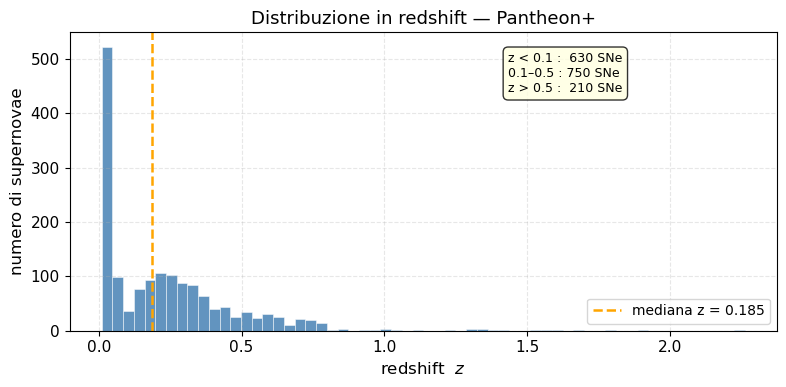

Salvato: plot1_redshift_distribution.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
 
ax.hist(z, bins=60, color="steelblue", edgecolor="white",
        linewidth=0.4, alpha=0.85)
ax.axvline(np.median(z), color="orange", lw=1.8, linestyle="--",
           label=f"mediana z = {np.median(z):.3f}")
 
ax.set_xlabel("redshift  $z$", fontsize=12)
ax.set_ylabel("numero di supernovae", fontsize=12)
ax.set_title("Distribuzione in redshift — Pantheon+", fontsize=13)
ax.legend(fontsize=10)
 
# Annotazione: quante SNe in tre bin
n_low  = np.sum(z < 0.1)
n_mid  = np.sum((z >= 0.1) & (z < 0.5))
n_high = np.sum(z >= 0.5)
ax.text(0.62, 0.80,
        f"z < 0.1 :  {n_low} SNe\n"
        f"0.1–0.5 : {n_mid} SNe\n"
        f"z > 0.5 :  {n_high} SNe",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4", fc="lightyellow", alpha=0.8))
 
plt.tight_layout()
plt.savefig("plot_dataset/plot1_redshift_distribution.png", dpi=150)
plt.show()
print("Salvato: plot1_redshift_distribution.png")

## Hubble diagram raw


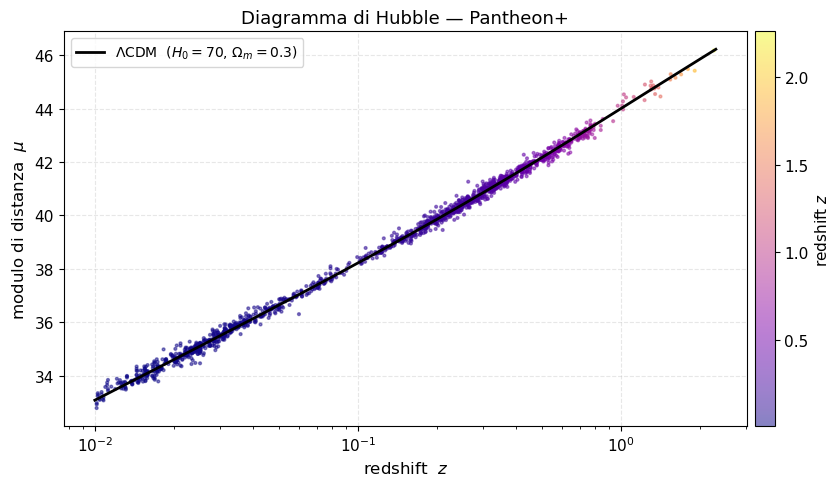

Salvato: plot2_hubble_diagram.png


In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
 
sc = ax.scatter(z, mu_obs, c=z, cmap="plasma",
                s=4, alpha=0.5, zorder=3)
plt.colorbar(sc, ax=ax, label="redshift $z$", pad=0.01)
 
# Curva del modello di riferimento
z_line = np.linspace(0.01, 2.3, 300)
mu_line = np.array([mu_lcdm(zi) for zi in z_line]) + M_offset
ax.plot(z_line, mu_line, "k-", lw=2, zorder=4,
        label=r"$\Lambda$CDM  ($H_0=70$, $\Omega_m=0.3$)")
 
ax.set_xlabel("redshift  $z$", fontsize=12)
ax.set_ylabel(r"modulo di distanza  $\mu$", fontsize=12)
ax.set_title("Diagramma di Hubble — Pantheon+", fontsize=13)
ax.legend(fontsize=10)
 
plt.tight_layout()
plt.savefig("plot2_hubble_diagram.png", dpi=150)
plt.show()
print("Salvato: plot2_hubble_diagram.png")


/Users/piter/miniconda3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/piter/miniconda3/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


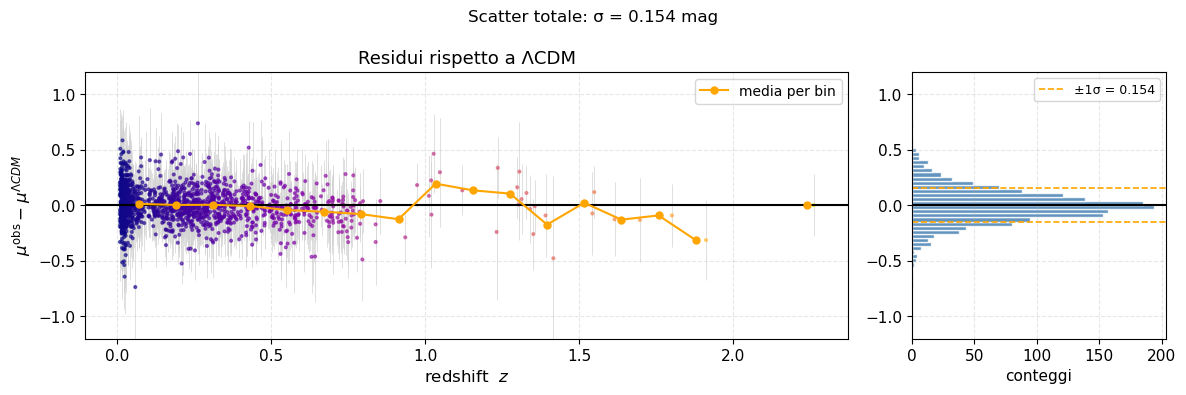

Salvato: plot3_residuals.png


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4),
                                 gridspec_kw={"width_ratios": [3, 1]})
 
# Scatter dei residui
ax1.errorbar(z, residuals, yerr=mu_err,
             fmt="none", ecolor="lightgray", elinewidth=0.5, zorder=1)
ax1.scatter(z, residuals, c=z, cmap="plasma",
            s=4, alpha=0.6, zorder=2)
ax1.axhline(0, color="black", lw=1.5, zorder=3)
 
# Bin medi per vedere trend
z_bins   = np.linspace(0.01, 2.3, 20)
z_mid    = 0.5 * (z_bins[:-1] + z_bins[1:])
res_mean = [np.mean(residuals[(z >= z_bins[i]) & (z < z_bins[i+1])])
            for i in range(len(z_bins)-1)]
ax1.plot(z_mid, res_mean, "o-", color="orange",
         ms=5, lw=1.5, zorder=4, label="media per bin")
 
ax1.set_xlabel("redshift  $z$", fontsize=12)
ax1.set_ylabel(r"$\mu^{\rm obs} - \mu^{\Lambda CDM}$", fontsize=12)
ax1.set_title("Residui rispetto a ΛCDM", fontsize=13)
ax1.set_ylim(-1.2, 1.2)
ax1.legend(fontsize=10)
 
# Istogramma dei residui
ax2.hist(residuals, bins=40, orientation="horizontal",
         color="steelblue", edgecolor="white", lw=0.4, alpha=0.85)
ax2.axhline(0, color="black", lw=1.5)
ax2.axhline(np.std(residuals),  color="orange", lw=1.2,
            linestyle="--", label=f"±1σ = {np.std(residuals):.3f}")
ax2.axhline(-np.std(residuals), color="orange", lw=1.2, linestyle="--")
ax2.set_xlabel("conteggi", fontsize=11)
ax2.set_ylim(-1.2, 1.2)
ax2.legend(fontsize=9)
 
plt.suptitle(f"Scatter totale: σ = {np.std(residuals):.3f} mag",
             fontsize=12)
plt.tight_layout()
plt.savefig("plot3_residuals.png", dpi=150)
plt.show()
print("Salvato: plot3_residuals.png")

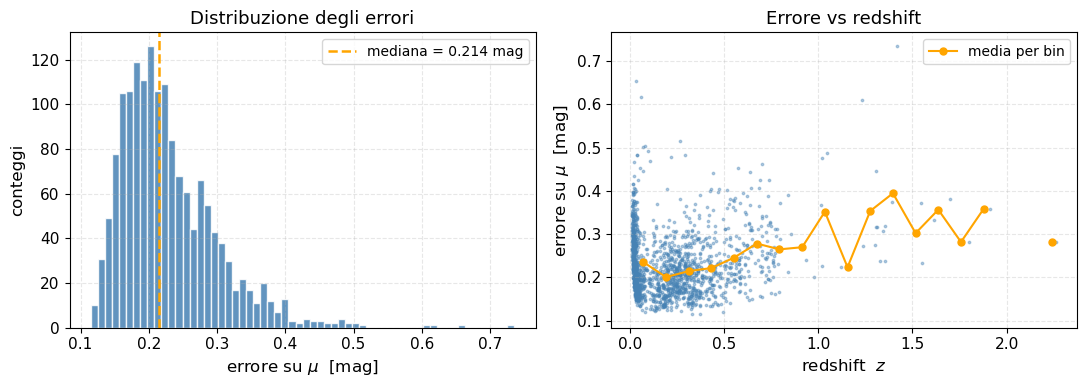

Salvato: plot4_errors.png


In [9]:
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
 
# Istogramma degli errori
ax1.hist(mu_err, bins=60, color="steelblue",
         edgecolor="white", lw=0.4, alpha=0.85)
ax1.axvline(np.median(mu_err), color="orange", lw=1.8,
            linestyle="--", label=f"mediana = {np.median(mu_err):.3f} mag")
ax1.set_xlabel(r"errore su $\mu$  [mag]", fontsize=12)
ax1.set_ylabel("conteggi", fontsize=12)
ax1.set_title("Distribuzione degli errori", fontsize=13)
ax1.legend(fontsize=10)
 
# Errore vs redshift
ax2.scatter(z, mu_err, s=3, alpha=0.4, color="steelblue")
# Trend medio
z_bins   = np.linspace(0.01, 2.3, 20)
z_mid    = 0.5 * (z_bins[:-1] + z_bins[1:])
err_mean = [np.mean(mu_err[(z >= z_bins[i]) & (z < z_bins[i+1])])
            for i in range(len(z_bins)-1)]
ax2.plot(z_mid, err_mean, "o-", color="orange", ms=5, lw=1.5,
         label="media per bin")
ax2.set_xlabel("redshift  $z$", fontsize=12)
ax2.set_ylabel(r"errore su $\mu$  [mag]", fontsize=12)
ax2.set_title("Errore vs redshift", fontsize=13)
ax2.legend(fontsize=10)
 
plt.tight_layout()
plt.savefig("plot4_errors.png", dpi=150)
plt.show()
print("Salvato: plot4_errors.png")

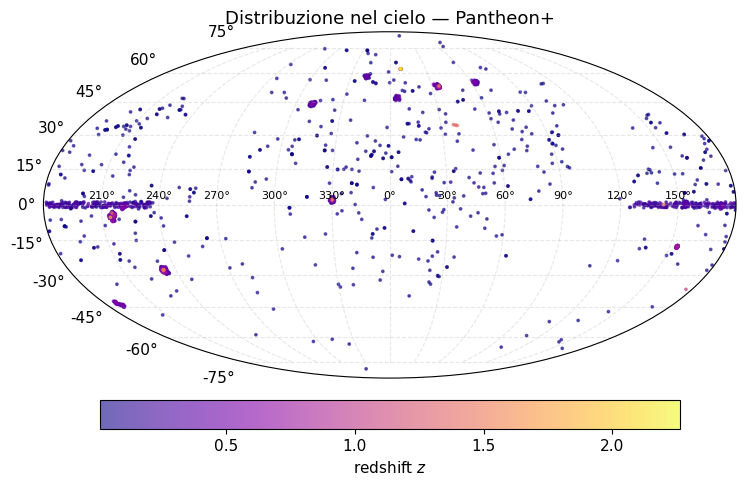

Salvato: plot5_skymap.png


In [10]:
# Controlla se le colonne RA/DEC esistono
if "RA" in df_cos.columns and "DEC" in df_cos.columns:
    ra  = df_cos["RA"].values
    dec = df_cos["DEC"].values
 
    # Converti in radianti per la proiezione di Mollweide
    # RA va da 0 a 360 -> da -180 a 180
    ra_rad  = np.deg2rad(ra - 180)
    dec_rad = np.deg2rad(dec)
 
    fig = plt.figure(figsize=(10, 5))
    ax  = fig.add_subplot(111, projection="mollweide")
 
    sc = ax.scatter(ra_rad, dec_rad, c=z, cmap="plasma",
                    s=3, alpha=0.6)
    plt.colorbar(sc, ax=ax, label="redshift $z$",
                 orientation="horizontal", pad=0.05, shrink=0.6)
 
    ax.set_title("Distribuzione nel cielo — Pantheon+", fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.set_xticklabels(["210°","240°","270°","300°","330°",
                         "0°","30°","60°","90°","120°","150°"],
                        fontsize=8)
 
    plt.tight_layout()
    plt.savefig("plot5_skymap.png", dpi=150)
    plt.show()
    print("Salvato: plot5_skymap.png")
else:
    print("Colonne RA/DEC non trovate, salto la mappa del cielo.")

<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
/var/folders/_3/d51kyvks4z383nhtd29lybxh0000gn/T/ipykernel_47333/1683657688.py:28: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel("errore su $\mu$ [mag]", fontsize=12)


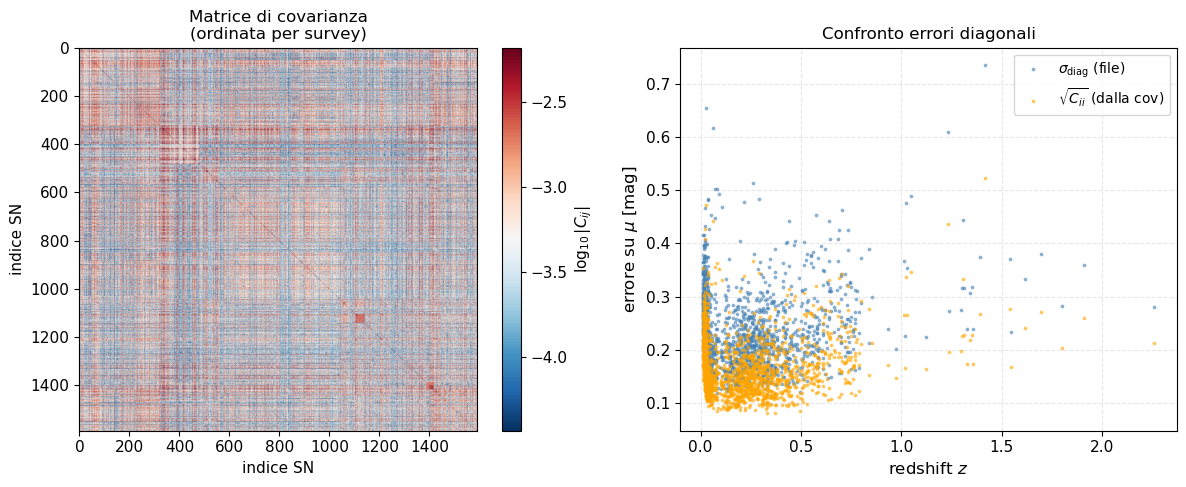

Salvato: plot6_covariance.png


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
 
# Visualizza la matrice intera (riordinata per survey)
# Usa scala logaritmica per vedere sia i picchi che le code
cov_diag_vals = np.diag(cov)
 
# Ordina le SNe per survey ID per vedere i blocchi
sort_idx   = np.argsort(surveys)
cov_sorted = cov[np.ix_(sort_idx, sort_idx)]
 
im = ax1.imshow(
    np.log10(np.abs(cov_sorted) + 1e-10),
    cmap="RdBu_r", aspect="auto",
    vmin=np.percentile(np.log10(np.abs(cov)+1e-10), 5),
    vmax=np.percentile(np.log10(np.abs(cov)+1e-10), 99)
)
plt.colorbar(im, ax=ax1, label=r"$\log_{10}|C_{ij}|$")
ax1.set_title("Matrice di covarianza\n(ordinata per survey)", fontsize=12)
ax1.set_xlabel("indice SN", fontsize=11)
ax1.set_ylabel("indice SN", fontsize=11)
 
# Confronto: errore diagonale vs sqrt(C_ii)
ax2.scatter(z, mu_err, s=3, alpha=0.5, label=r"$\sigma_{\rm diag}$ (file)",
            color="steelblue")
ax2.scatter(z, np.sqrt(cov_diag_vals), s=3, alpha=0.5,
            label=r"$\sqrt{C_{ii}}$ (dalla cov)", color="orange")
ax2.set_xlabel("redshift $z$", fontsize=12)
ax2.set_ylabel("errore su $\mu$ [mag]", fontsize=12)
ax2.set_title("Confronto errori diagonali", fontsize=12)
ax2.legend(fontsize=10)
 
plt.tight_layout()
plt.savefig("plot6_covariance.png", dpi=150)
plt.show()
print("Salvato: plot6_covariance.png")
 

In [12]:
print("\n" + "="*50)
print("STATISTICHE RIASSUNTIVE")
print("="*50)
print(f"Supernovae totali nel dataset:     {len(df)}")
print(f"Supernovae dopo taglio z>0.01:     {len(df_cos)}")
print(f"Range redshift:                    {z.min():.4f} – {z.max():.4f}")
print(f"Mediana redshift:                  {np.median(z):.4f}")
print(f"Range modulo di distanza:          {mu_obs.min():.2f} – {mu_obs.max():.2f} mag")
print(f"Errore medio su mu:                {mu_err.mean():.4f} mag")
print(f"Errore mediano su mu:              {np.median(mu_err):.4f} mag")
print(f"Scatter residui (sigma):           {np.std(residuals):.4f} mag")
print(f"Survey diversi presenti:           {df_cos['IDSURVEY'].nunique()}")
print(f"Correlazione media off-diag (cov): {np.mean(np.abs(cov[~np.eye(len(cov), dtype=bool)])):.6f}")


STATISTICHE RIASSUNTIVE
Supernovae totali nel dataset:     1701
Supernovae dopo taglio z>0.01:     1590
Range redshift:                    0.0102 – 2.2614
Mediana redshift:                  0.1846
Range modulo di distanza:          32.78 – 46.18 mag
Errore medio su mu:                0.2288 mag
Errore mediano su mu:              0.2143 mag
Scatter residui (sigma):           0.1541 mag
Survey diversi presenti:           20
Correlazione media off-diag (cov): 0.000892


In [4]:
mask_local = df["zHD"] <= 0.01
print(f"SNe con z < 0.01: {mask_local.sum()}")
print(df[mask_local][["zHD", "MU_SH0ES", "CEPH_DIST"]].head(20))

SNe con z < 0.01: 111
        zHD  MU_SH0ES  CEPH_DIST
0   0.00122   28.9987    29.1770
1   0.00122   29.0559    29.1770
2   0.00256   30.7233    30.8433
3   0.00256   30.7449    30.8433
4   0.00299   30.7757    -9.0000
5   0.00317   30.7946    30.8338
6   0.00331   30.4604    30.5454
7   0.00331   30.5528    30.5454
8   0.00331   30.4013    30.5454
9   0.00331   30.5107    30.5454
10  0.00333   31.5011    31.2859
11  0.00349   31.7933    31.6336
12  0.00349   31.4967    31.7216
13  0.00359   31.6969    31.8115
14  0.00384   30.9999    31.2859
15  0.00407   31.3933    31.4903
16  0.00407   31.3779    31.4903
17  0.00432   31.4990    31.6272
18  0.00432   31.5611    31.6272
19  0.00465   31.9309    31.9348


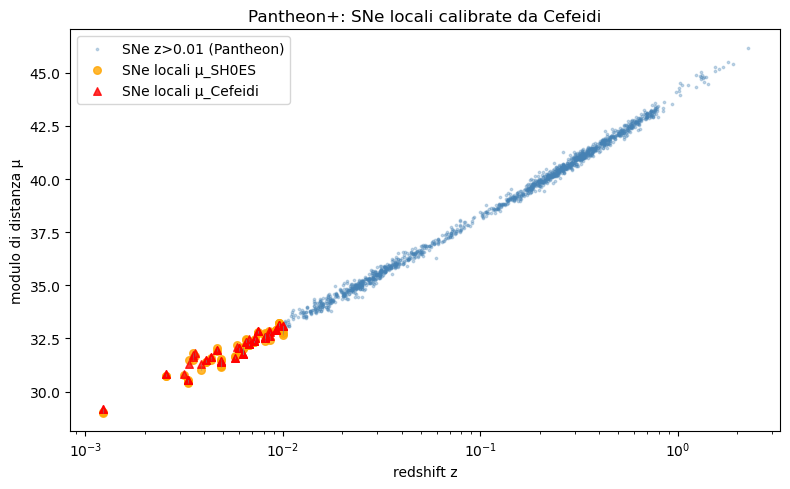

In [5]:
df_all = pd.read_csv("Pantheon+SH0ES.dat", sep=r'\s+')
mask_local = df_all["zHD"] <= 0.01
mask_ceph = df_all["CEPH_DIST"] > 0 # esclude -9.0
df_local = df_all[mask_local & mask_ceph]

fig, ax = plt.subplots(figsize=(8, 5))

# tutte le SNe lontane (già nel tuo fit)
df_far = df_all[df_all["zHD"] > 0.01]
ax.scatter(df_far["zHD"], df_far["MU_SH0ES"],
           s=3, alpha=0.3, color="steelblue", label="SNe z>0.01 (Pantheon)")

# SNe locali: MU_SH0ES vs CEPH_DIST
ax.scatter(df_local["zHD"], df_local["MU_SH0ES"],
           s=30, alpha=0.8, color="orange", label="SNe locali μ_SH0ES")
ax.scatter(df_local["zHD"], df_local["CEPH_DIST"],
           s=30, alpha=0.8, color="red", marker="^", label="SNe locali μ_Cefeidi")

# linee che collegano μ_SH0ES e μ_Cefeidi per ogni SN locale
for _, row in df_local.iterrows():
    ax.plot([row["zHD"], row["zHD"]],
            [row["MU_SH0ES"], row["CEPH_DIST"]],
            color="gray", lw=0.5, alpha=0.5)

ax.set_xlabel("redshift z")
ax.set_ylabel("modulo di distanza μ")
ax.set_title("Pantheon+: SNe locali calibrate da Cefeidi")
ax.legend()
ax.set_xscale("log")
plt.tight_layout()
plt.show()

Le SNe locali (arancione) sono i punti μ_SH0ES a z < 0.01. I triangoli rossi sono la misura indipendente delle Cefeidi per la stessa SN. Le linee grigie collegano le due misure — la loro differenza è esattamente l'offset di calibrazione assoluta che ancora H0.